# Phase3_Unsupervised_Learning

**Course:** SWE 485  
**Notebook:** Phase3_Unsupervised_Learning.ipynb  


## 1. Setup & Imports

In [12]:
# === Phase 3 - Clustering within the IT category ===

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 2. Data Loading & Preparation for IT Cluster Analysis

In Phase 2, the supervised model was trained to predict the **job category**.  
For Phase 3, the focus is on enhancing the model by discovering hidden sub-groups **inside a single category** (Information-Technology).

Steps:

1. **Filter the dataset** to keep only rows where `category = "Information-Technology"`.  
   This allows exploration of sub-specialties within IT (e.g., Data Science, Networking, Web Development).

2. **Store `job_title` externally** in `job_title_labels`.  
   It will be used later to interpret the discovered clusters, but is **not** used as an input feature.  
   This follows the handbook instruction to *"remove the class label before clustering"*.

3. **Clean the skill set** by removing brackets and quotes, producing `job_skill_set_cleaned`.

4. **Build a new text feature** called `text_unsupervised` by combining:
   - `job_description`
   - `job_skill_set_cleaned`

   This text represents the *content* of the job posting (what the job is about), without leaking the `job_title` label into the clustering input.


In [ ]:
# === Load dataset ===

import pandas as pd

DATA_PATH = r"c:/Users/rana0/Documents/GitHub/SWE485-Project-Group7/Dataset/jobs_dataset_raw.csv"

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print("Original shape:", df.shape)

# === Detect IT category name and filter only IT rows ===

print("Unique category values:", df["category"].unique())

df["category_clean"] = df["category"].astype(str).str.strip().str.lower()

it_mask = df["category_clean"].str.contains("information", na=False)
df_it = df[it_mask].copy()

print("IT-only shape:", df_it.shape)

# === Save job_title as label ===
job_title_labels = df_it["job_title"]

# === Clean the skills column ===
df_it["job_skill_set_cleaned"] = (
    df_it["job_skill_set"]
    .astype(str)
    .str.strip("[]'")
    .str.replace("', '", " ", regex=False)
)

# === Build the unsupervised text feature ===
df_it["text_unsupervised"] = (
    df_it["job_description"].fillna("") + " " +
    df_it["job_skill_set_cleaned"].fillna("")
)

print(df_it[["job_title", "category", "text_unsupervised"]].head())


Loaded: c:/Users/rana0/Documents/GitHub/SWE485-Project-Group7/Dataset/jobs_dataset_raw.csv
Original shape: (1167, 5)
Unique category values: ['HR' 'INFORMATION-TECHNOLOGY' 'SALES' 'FINANCE' 'BUSINESS-DEVELOPMENT']
IT-only shape: (240, 6)
                                             job_title  \
220             Information Technology Project Manager   
221            Information Technology Security Analyst   
222  Application Analyst I, Day Shift, Information ...   
223                  Information Technology Specialist   
224          Information Technology Support Technician   

                   category                                  text_unsupervised  
220  INFORMATION-TECHNOLOGY  JOB TITLE: PROJECT MANAGER LOCATION: TALLAHASS...  
221  INFORMATION-TECHNOLOGY  FULL JOB DESCRIPTIONAS AN INFORMATION SECURITY...  
222  INFORMATION-TECHNOLOGY  SUPPORT CENTER\r\n\r\nIF YOU ARE A CURRENT ADV...  
223  INFORMATION-TECHNOLOGY  COMPANY DESCRIPTION\r\n ENSPYRE MANAGEMENT SER...  
224  INF

## 3. TF-IDF Representation for IT Jobs

The `text_unsupervised` column is transformed into a TF-IDF feature space using:

- English stop-word removal  
- Unigrams and bigrams (`ngram_range = (1, 2)`)  
- `min_df = 2` to drop extremely rare terms

The resulting sparse matrix is used as input to the K-Means clustering algorithm.

In [9]:
# === TF-IDF vectorization ===

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1
)

X_it_tfidf = tfidf_vectorizer.fit_transform(df_it["text_unsupervised"].astype(str))

print("TF-IDF matrix shape:", X_it_tfidf.shape)


TF-IDF matrix shape: (240, 56330)


## 4. WCSS Analysis (Elbow Method)

To estimate a suitable number of clusters **k** for the IT jobs,  
the **Within-Cluster Sum of Squares (WCSS)** is computed for different values of k (from 2 to 10).

- WCSS measures how compact the clusters are: lower WCSS means that points are closer to their cluster centroids.
- In the **Elbow Method**, a value of k is chosen where the decrease in WCSS starts to slow down  
  (the “elbow” point in the curve).

This provides an initial candidate range for k to validate with Silhouette Scores.


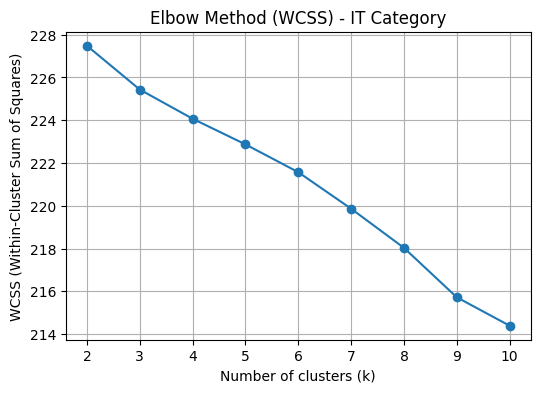

WCSS values: {2: 227.48592631479477, 3: 225.43607329645351, 4: 224.07067955342015, 5: 222.8709885768641, 6: 221.5703918451416, 7: 219.86220691215257, 8: 218.03061677389098, 9: 215.71762689314792, 10: 214.38868966543453}


In [ ]:
# === WCSS: Elbow Method for IT TF-IDF Clusters ===

wcss = []
K = range(2, 11)  

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    kmeans.fit(X_it_tfidf)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K, wcss, marker="o")
plt.title("Elbow Method (WCSS) - IT Category")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.grid(True)
plt.show()

print("WCSS values:", dict(zip(K, wcss)))

## 5. Silhouette Analysis

The choice of **k** is further evaluated using the **Silhouette Score**:

- The Silhouette Score captures how well-separated and cohesive the clusters are:
  - A value close to **1.0** indicates very well-separated clusters.
  - A value near **0** indicates overlapping clusters.
  - Negative values suggest that many points may be assigned to the wrong cluster.

By comparing the Silhouette Scores across k values,  
the k that gives the **highest** score (or a good trade-off between score and interpretability) is selected.

Together with the Elbow Method, this provides a justified choice for the number of IT sub-clusters that will be used in the next step (cluster interpretation and integration with the supervised model).


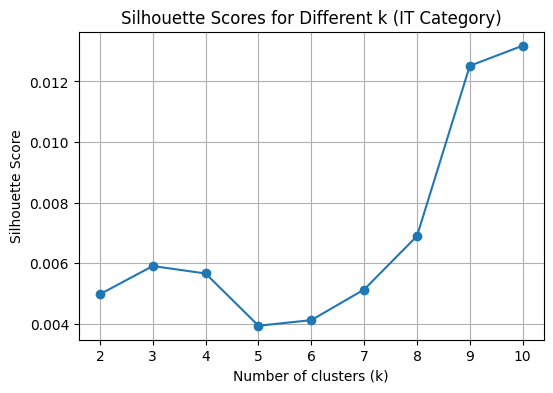

Silhouette scores: {2: 0.0049765569399664224, 3: 0.00590714099723399, 4: 0.0056609307305807285, 5: 0.003936833276159246, 6: 0.0041206843472688885, 7: 0.005131018315747569, 8: 0.006894510307199544, 9: 0.012515675987283906, 10: 0.013179378115666636}


In [11]:
# === Silhouette Scores for IT Clusters ===

silhouette_scores = []

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto"
    )
    labels_k = kmeans.fit_predict(X_it_tfidf)
    score = silhouette_score(X_it_tfidf, labels_k)
    silhouette_scores.append(score)

plt.figure(figsize=(6, 4))
plt.plot(K, silhouette_scores, marker="o")
plt.title("Silhouette Scores for Different k (IT Category)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

print("Silhouette scores:", dict(zip(K, silhouette_scores)))